# 🎮 Four Decades of GPUs: Market Consolidation, Memory, and Architecture Shifts

## ✨ Background

The graphics card market started out crowded. In the late 1990s, buyers could choose among cards from ATI, NVIDIA, 3dfx, Matrox, Intel, and others. Today, PC graphics is a three-way race between NVIDIA, AMD, and Intel. Along the way, GPUs went through several technology transitions:

- separate pixel and vertex shaders gave way to **unified shaders**,
- the PCI bus gave way to **AGP** and then several generations of **PCI Express**,
- graphics memory moved from SDR/DDR through **GDDR3, GDDR5, GDDR6**, and stacked **HBM**.

This notebook uses a product-level GPU specification dataset to trace these shifts. It also turned up a data quality problem: in the latest version of the dataset, most of the spec columns are scrambled.

## ♟️ About the Dataset

- **Source:** [NVIDIA & AMD GPUs Full Specs](https://www.kaggle.com/datasets/alanjo/graphics-card-full-specs) on Kaggle (CC0 license), web-scraped from the [TechPowerUp GPU Database](https://www.techpowerup.com/gpu-specs/). The Kaggle dataset was last updated in August 2024 and includes two files:
  - `gpu_specs_v7.csv`: the latest version, with 3,056 products released 1986–2025. The author's original analysis used this file.
  - `gpu_specs_v6.csv`: the previous version, with 2,889 products released 1986–2023. It is used below to check and replace v7's spec columns.
- **One row = one product (SKU)**, such as "GeForce GTX 1080" or "Radeon HD 4870". Rows are product launches, not unit sales. "Share" in this notebook always means *share of products released*, not market share by revenue or shipments.
- **Columns:** manufacturer, product name, release year, memory size (GB) and bus width (bits), GPU and memory clocks (MHz), shader/TMU/ROP counts, an integrated-GPU flag (`igp`), bus interface, memory type, and GPU chip codename.
- **Coverage:** eight manufacturers (NVIDIA, AMD, ATI, Intel, Matrox, 3dfx, XGI, and Sony). Other historical vendors such as S3, 3Dlabs, and PowerVR are not in the data.

## ❓ Questions

1. How did the set of GPU makers consolidate, and who released the most products over time?
2. Can the spec columns be trusted? (Spoiler: in v7 they can't. See the data integrity check.)
3. When did unified shaders replace separate pixel/vertex shaders?
4. How fast has graphics memory grown, and is that growth slowing down?
5. How did memory types and bus interfaces turn over, and how does the mix of integrated and discrete GPUs differ by vendor?

---

Import packages.


In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

In [2]:
import plotly

print(f'pandas version: {pd.__version__}')
print(f'plotly version: {plotly.__version__}')

pandas version: 3.0.6
plotly version: 7.1.0


Set a default theme for Plotly.

In [3]:
pio.templates['sans_serif'] = go.layout.Template(dict(    
    layout=go.Layout(
           font_family='Helvetica, Inter, Arial, sans-serif',
    ),
))

pio.templates.default = "simple_white+sans_serif"

## 📂 Load Data

Load the latest version of the dataset (`gpu_specs_v7.csv`).

In [4]:
df = pd.read_csv('gpu_specs_v7.csv')
df.head(3)

,manufacturer,productName,releaseYear,memSize,memBusWidth,gpuClock,memClock,unifiedShader,tmu,rop,pixelShader,vertexShader,igp,bus,memType,gpuChip
0,NVIDIA,GeForce RTX 5090,2025.0,28.0,448.0,900,1200.0,8192.0,256,128,NaN,NaN,No,PCIe 4.0 x16,HBM2e,Arctic Sound
1,NVIDIA,GeForce RTX 5080,2025.0,16.0,256.0,900,1215.0,6912.0,432,192,NaN,NaN,No,PCIe 4.0 x16,HBM2e,GA100
2,NVIDIA,GeForce RTX 5070,2025.0,12.0,192.0,1825,2000.0,5120.0,320,128,NaN,NaN,No,PCIe 4.0 x16,GDDR6,Navi 21


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3056 entries, 0 to 3055
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   manufacturer   3056 non-null   str    
 1   productName    3056 non-null   str    
 2   releaseYear    3012 non-null   float64
 3   memSize        2615 non-null   float64
 4   memBusWidth    188 non-null    float64
 5   gpuClock       3056 non-null   int64  
 6   memClock       2615 non-null   float64
 7   unifiedShader  2232 non-null   float64
 8   tmu            3056 non-null   int64  
 9   rop            3056 non-null   int64  
 10  pixelShader    824 non-null    float64
 11  vertexShader   824 non-null    float64
 12  igp            3056 non-null   str    
 13  bus            3056 non-null   str    
 14  memType        2615 non-null   str    
 15  gpuChip        3056 non-null   str    
dtypes: float64(7), int64(3), str(6)
memory usage: 510.1 KB


- 3,056 rows and 16 columns.
- `releaseYear` is a float because some years are missing.
- `memBusWidth` has only 188 non-null values.


Check the number of missing values.

In [6]:
df_missing = df.isna().sum() \
    .to_frame(name='num_missing_values') \
    .reset_index(names=['column']) \
    .sort_values('num_missing_values', ascending=True)

df_missing

,column,num_missing_values
0,manufacturer,0
1,productName,0
5,gpuClock,0
15,gpuChip,0
12,igp,0
13,bus,0
9,rop,0
8,tmu,0
2,releaseYear,44
14,memType,441


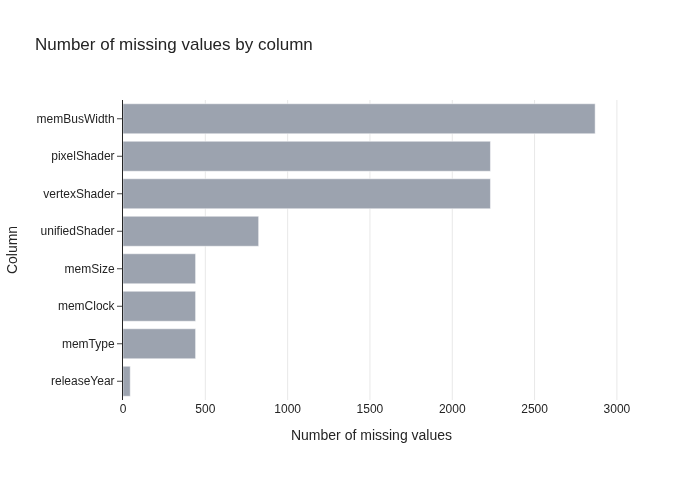

In [7]:
df_plot = df_missing.query('`num_missing_values` > 0')

fig = px.bar(
    df_plot,
    x='num_missing_values',
    y='column',
    labels={
        'num_missing_values': 'Number of missing values',
        'column': 'Column'
    },
    title='Number of missing values by column',
    height=df_plot.shape[0]*60,
)

fig.update_traces(marker_color='#9CA3AF')
fig.update_xaxes(
    showline=False,
    showgrid=True,
    linecolor='#F3F4F6',
    linewidth=1,
    ticks='',
)

fig.show()

What the missing values mean:

- **`memBusWidth`** is missing for 2,868 of 3,056 rows (94%). In v7 it is filled only for products released in 2022 or later, so this analysis does not use it.
- **`unifiedShader`** (824 missing) and **`pixelShader`/`vertexShader`** (2,232 missing) complement each other: 824 + 2,232 = 3,056. A GPU reports either unified shaders (newer designs) or separate pixel/vertex shaders (older designs), not both.
- **`memSize`, `memClock`, `memType`** are each missing for 441 rows. Integrated GPUs share system memory and have no dedicated memory size.
- **`releaseYear`** is missing for 44 rows (see below).


In [8]:
df.head(3)

,manufacturer,productName,releaseYear,memSize,memBusWidth,gpuClock,memClock,unifiedShader,tmu,rop,pixelShader,vertexShader,igp,bus,memType,gpuChip
0,NVIDIA,GeForce RTX 5090,2025.0,28.0,448.0,900,1200.0,8192.0,256,128,NaN,NaN,No,PCIe 4.0 x16,HBM2e,Arctic Sound
1,NVIDIA,GeForce RTX 5080,2025.0,16.0,256.0,900,1215.0,6912.0,432,192,NaN,NaN,No,PCIe 4.0 x16,HBM2e,GA100
2,NVIDIA,GeForce RTX 5070,2025.0,12.0,192.0,1825,2000.0,5120.0,320,128,NaN,NaN,No,PCIe 4.0 x16,GDDR6,Navi 21


### 📅 Release-year sanity check

`releaseYear` is stored as a float because 44 rows have no release year. What are those rows?

In [9]:
df_no_year = df[df['releaseYear'].isna()]

print(f'{df_no_year.shape[0]} products have no release year.')
df_no_year[['manufacturer', 'productName', 'memSize']].head(10)

44 products have no release year.


,manufacturer,productName,memSize
3012,AMD,Radeon R9 FURY X2,4.000
3013,AMD,Radeon RX Vega Nano,8.000
3014,ATI,Radeon HD 2900 XTX,0.512
3015,AMD,Radeon R9 285X,3.000
3016,NVIDIA,GeForce GTX 780 Ti 6 GB,6.000
3017,NVIDIA,GeForce GTX 490,1.536
3018,NVIDIA,GeForce GTX 480 Core 512,1.536
3019,NVIDIA,GeForce GTX 470 PhysX Edition,1.280
3020,NVIDIA,GeForce GTX 1080 Ti 10 GB,10.000
3021,AMD,Radeon RX 6900 XTX,16.000


The products without a release year look like cancelled or never-released cards, such as the Radeon HD 2900 XTX and GeForce GTX 490. They are excluded from the time-series analysis.

Next, check the most recent years.


In [10]:
num_products_recent = df['releaseYear'].value_counts().sort_index().tail(6)
num_products_recent.index = num_products_recent.index.astype(int)

num_products_recent.to_frame(name='num_products').T

releaseYear,2020,2021,2022,2023,2024,2025
num_products,86,88,98,100,21,6


In [11]:
df.query('releaseYear == 2025')[['manufacturer', 'productName', 'releaseYear', 'memSize', 'memBusWidth']]

,manufacturer,productName,releaseYear,memSize,memBusWidth
0,NVIDIA,GeForce RTX 5090,2025.0,28.0,448.0
1,NVIDIA,GeForce RTX 5080,2025.0,16.0,256.0
2,NVIDIA,GeForce RTX 5070,2025.0,12.0,192.0
3,NVIDIA,GeForce RTX 5060 Mobile,2025.0,8.0,128.0
4,NVIDIA,GeForce RTX 5060,2025.0,8.0,128.0
5,NVIDIA,GeForce RTX 5050,2025.0,8.0,128.0


The last two years look incomplete:

- **2024** has only 21 products (compared with about 100 per year in 2022–2023). The dataset was last updated in August 2024, so 2024 covers only part of the year.
- **2025** has 6 products, all NVIDIA RTX 50-series cards that had not launched when the data was collected. At least one listing is a placeholder. The GeForce RTX 5090 is listed with 28 GB on a 448-bit bus, but the card that launched in January 2025 has 32 GB on a 512-bit bus.

If these partial years stay in, the share charts below show NVIDIA at 100% of 2025. Time-series analysis is therefore limited to products released **through 2023**. `releaseYear` is also converted to an integer.


In [12]:
df = df.query('releaseYear <= 2023').copy()
df['releaseYear'] = df['releaseYear'].astype(int)

print(f"{df.shape[0]:,} products released between {df['releaseYear'].min()} and {df['releaseYear'].max()} remain.")

2,985 products released between 1986 and 2023 remain.


## 🏁 Market Structure: Who Releases GPUs?

### Products released per year

Count the number of products by manufacturer and release year.

In [13]:
df_manufacturer_year = df.groupby(['manufacturer', 'releaseYear'], as_index=False).agg({
    'productName': 'count'
}).rename(columns={
    'productName': 'count'
})

df_manufacturer_year

,manufacturer,releaseYear,count
0,3dfx,1996,1
1,3dfx,1998,4
2,3dfx,1999,7
3,3dfx,2000,4
4,AMD,2006,1
...,...,...,...
113,Sony,2005,1
114,Sony,2007,2
115,Sony,2011,1
116,XGI,2003,14


Keep AMD and NVIDIA and group every other manufacturer (including ATI, which AMD acquired in 2006) into "Other".

In [14]:
df_manufacturer_year = df.copy()
df_manufacturer_year.loc[~df_manufacturer_year['manufacturer'].isin(['AMD', 'NVIDIA']), 'manufacturer'] = 'Other'

df_manufacturer_year = df_manufacturer_year.groupby(['manufacturer', 'releaseYear'], as_index=False).agg({
    'productName': 'count'
}).rename(columns={
    'productName': 'count'
})

df_manufacturer_year

,manufacturer,releaseYear,count
0,AMD,2006,1
1,AMD,2007,1
2,AMD,2008,2
3,AMD,2009,1
4,AMD,2010,18
...,...,...,...
77,Other,2019,6
78,Other,2020,13
79,Other,2021,9
80,Other,2022,26


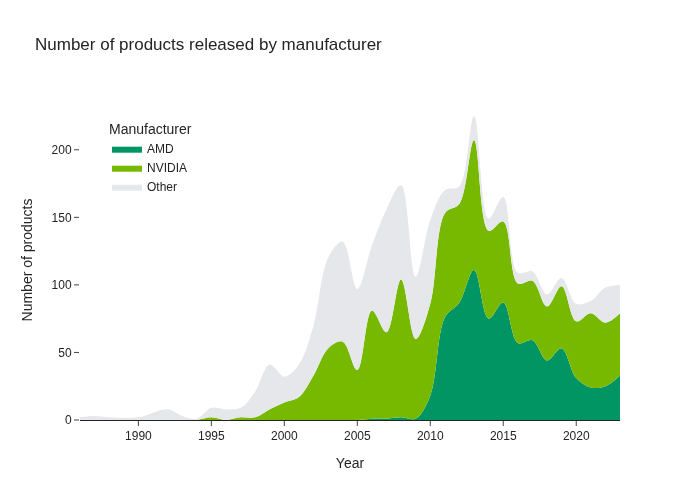

In [15]:
fig = px.area(
    df_manufacturer_year,
    x='releaseYear',
    y='count',
    color='manufacturer',
    labels={
        'count': 'Number of products',
        'releaseYear': 'Year',
        'manufacturer': 'Manufacturer',
    },
    title='Number of products released by manufacturer',
    color_discrete_map={
        'AMD': '#009563',
        'NVIDIA': '#76b900',
        'Other': '#E5E7EB',
    },
    line_shape='spline',
    height=500,
)

fig.for_each_trace(lambda trace: trace.update(fillcolor = trace.line.color))
fig.update_yaxes(showline=False)
fig.update_traces(line={'width': 0})
fig.update_layout(
    hovermode='x',
    legend=dict(
        yanchor='top',
        xanchor='left',
        y=0.95,
        x=0.05
    )
)

fig.show()

In [16]:
num_products_per_year = df.groupby('releaseYear').size()

print(f'Peak year: {num_products_per_year.idxmax()} ({num_products_per_year.max()} products)')
print(f'Products per year, 2019–2023: {num_products_per_year.loc[2019:2023].to_dict()}')

Peak year: 2013 (225 products)
Products per year, 2019–2023: {2019: 105, 2020: 86, 2021: 88, 2022: 98, 2023: 100}


- Product launches peaked in **2013 at 225 products**. Since 2020 the count has stayed between 86 and 100 per year. The vendors now release fewer distinct SKUs than they did in the early 2010s.
- Before 2010, most of the gray "Other" area is **ATI**. AMD bought ATI in 2006, but the dataset kept the ATI label on most Radeon products until 2010. AMD's sudden "arrival" in 2010 is mostly a relabeling. The next chart shows ATI separately.


### Share of products released by manufacturer (since 1995)

Compute each manufacturer's share of the products released in each year. ATI is shaded as a lighter version of AMD's color because AMD acquired ATI in 2006 and kept selling ATI-branded Radeon and FirePro cards for a few more years.

In [17]:
df_manufacturer_year_1995 = df.copy()
df_manufacturer_year_1995 =df_manufacturer_year_1995.query('releaseYear >= 1995')

df_manufacturer_year_1995 = df_manufacturer_year_1995.groupby(['manufacturer', 'releaseYear'], as_index=False).agg({
    'productName': 'count'
}).rename(columns={
    'productName': 'count'
})

df_manufacturer_year_1995['year_percentage'] = df_manufacturer_year_1995['count'] / \
    df_manufacturer_year_1995.groupby('releaseYear')['count'].transform('sum')

df_manufacturer_year_1995

,manufacturer,releaseYear,count,year_percentage
0,3dfx,1996,1,0.125000
1,3dfx,1998,4,0.190476
2,3dfx,1999,7,0.170732
3,3dfx,2000,4,0.125000
4,AMD,2006,1,0.007752
...,...,...,...,...
106,Sony,2005,1,0.010309
107,Sony,2007,2,0.012821
108,Sony,2011,1,0.005882
109,XGI,2003,14,0.116667


In [18]:
list(reversed(['NVIDIA', 'Intel', 'XGI', 'Sony', 'Matrox', '3dfx', 'ATI', 'AMD']))

['AMD', 'ATI', '3dfx', 'Matrox', 'Sony', 'XGI', 'Intel', 'NVIDIA']

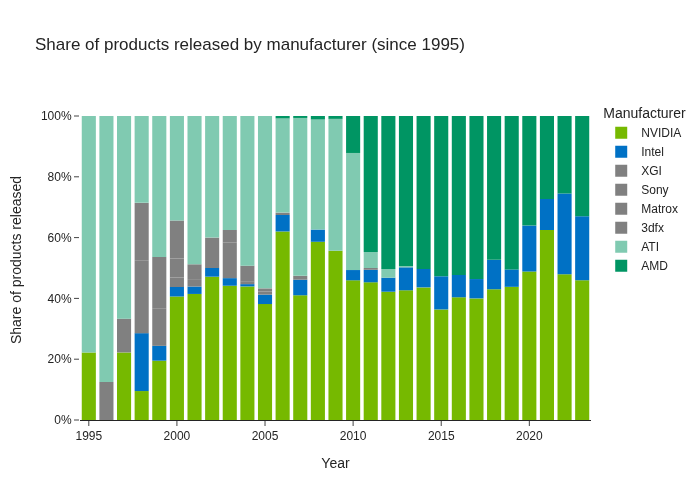

In [19]:
fig = px.bar(
    df_manufacturer_year_1995,
    x='releaseYear',
    y='year_percentage',
    color='manufacturer',
    labels={
        'count': 'Number of products',
        'year_percentage': 'Share of products released',
        'releaseYear': 'Year',
        'manufacturer': 'Manufacturer',
    },
    title='Share of products released by manufacturer (since 1995)',
    color_discrete_map={
        'AMD': '#009563',
        'ATI': '#80CAB1',
        '3dfx': 'gray',
        'Matrox': 'gray',
        'Sony': 'gray',
        'XGI': 'gray',
        'Intel': '#0071C5',
        'NVIDIA': '#76b900',
    },
    category_orders={
        'manufacturer': reversed(['AMD', 'ATI', '3dfx', 'Matrox', 
                                  'Sony', 'XGI', 'Intel', 'NVIDIA'])
    },
    height=500,
)

fig.update_yaxes(
    showline=False,
    tickformat='.0%',
)


fig.update_traces(marker=dict(line_width=0))

fig.show()

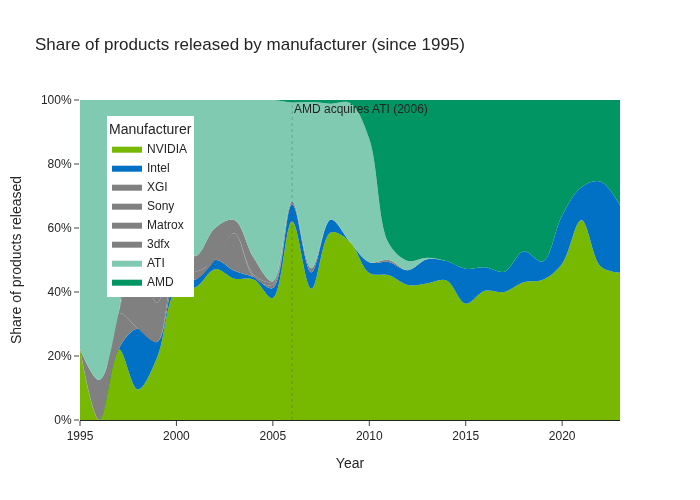

In [20]:
fig = px.area(
    df_manufacturer_year_1995,
    x='releaseYear',
    y='year_percentage',
    color='manufacturer',
    labels={
        'count': 'Number of products',
        'year_percentage': 'Share of products released',
        'releaseYear': 'Year',
        'manufacturer': 'Manufacturer',
    },
    title='Share of products released by manufacturer (since 1995)',
    color_discrete_map={
        'AMD': '#009563',
        'ATI': '#80CAB1',
        '3dfx': 'gray',
        'Matrox': 'gray',
        'Sony': 'gray',
        'XGI': 'gray',
        'Intel': '#0071C5',
        'NVIDIA': '#76b900',
    },
    category_orders={
        'manufacturer': reversed(['AMD', 'ATI', '3dfx', 'Matrox', 
                                  'Sony', 'XGI', 'Intel', 'NVIDIA'])
    },
    line_shape='spline',
    height=500,
)

fig.for_each_trace(lambda trace: trace.update(fillcolor = trace.line.color))
fig.update_yaxes(showline=False, tickformat='.0%')
fig.update_traces(line={'width': 0})
fig.update_layout(
    hovermode='x',
    legend=dict(
        yanchor='top',
        xanchor='left',
        y=0.95,
        x=0.05
    ),
    yaxis_range=[0, 1]
)
fig.add_vline(
    x=2006,
    line_dash='dot',
    line_color='#374151',
    line_width=1,
    annotation_text='AMD acquires ATI (2006)',
    annotation_position='top right',
)
fig.show()

Summarize the shares by era, folding ATI into AMD.

In [21]:
df_era = df.query('releaseYear >= 1995').copy()
df_era['vendor'] = df_era['manufacturer'].replace({'ATI': 'AMD'})
df_era.loc[~df_era['vendor'].isin(['AMD', 'NVIDIA', 'Intel']), 'vendor'] = 'Other'
df_era['era'] = pd.cut(
    df_era['releaseYear'],
    bins=[1994, 1999, 2005, 2010, 2015, 2020, 2023],
    labels=['1995–1999', '2000–2005', '2006–2010', '2011–2015', '2016–2020', '2021–2023'],
)

df_era_share = pd.crosstab(df_era['era'], df_era['vendor'], normalize='index') \
    .mul(100) \
    .round(1) \
    .rename(columns={'AMD': 'AMD + ATI (%)', 'NVIDIA': 'NVIDIA (%)', 'Intel': 'Intel (%)', 'Other': 'Other (%)'})
df_era_share['num_products'] = df_era['era'].value_counts().sort_index()

df_era_share[['NVIDIA (%)', 'AMD + ATI (%)', 'Intel (%)', 'Other (%)', 'num_products']]

vendor,NVIDIA (%),AMD + ATI (%),Intel (%),Other (%),num_products
era,,,,,
1995–1999,15.9,51.1,6.8,26.1,88
2000–2005,42.9,45.5,2.2,9.3,492
2006–2010,52.3,43.5,3.8,0.4,713
2011–2015,42.1,51.1,6.7,0.1,882
2016–2020,42.9,48.5,8.5,0.0,503
2021–2023,51.7,28.7,19.6,0.0,286


- **AMD (with ATI) and NVIDIA have split the product catalog for over 20 years.** NVIDIA released 42.1%–52.3% of products in each era from 2000 onward. AMD + ATI released 43.5%–51.1% until 2020.
- The early field was diverse. In 1995–1999, "Other" vendors (3dfx, Matrox, Sony) accounted for 26.1% of products. By 2006–2010 they were down to 0.4%.
- **Intel's share of releases grew from 2.2%–8.5% per era to 19.6% in 2021–2023**, the period of its Arc discrete GPUs. AMD + ATI fell to 28.7% in the same period.
- The early years (1995–1999) contain only 88 products, so their year-to-year swings are noisy.


### Vendor entries and exits

When did each manufacturer release its first and last product in the dataset?

In [22]:
df_vendor_span = df.groupby('manufacturer', as_index=False).agg(
    first_year=('releaseYear', 'min'),
    last_year=('releaseYear', 'max'),
    num_products=('productName', 'count'),
).sort_values('first_year')

df_vendor_span

,manufacturer,first_year,last_year,num_products
2,ATI,1986,2013,591
6,Sony,1994,2011,9
5,NVIDIA,1995,2023,1333
0,3dfx,1996,2000,16
4,Matrox,1998,2006,34
3,Intel,1998,2023,202
7,XGI,2003,2005,15
1,AMD,2006,2023,785


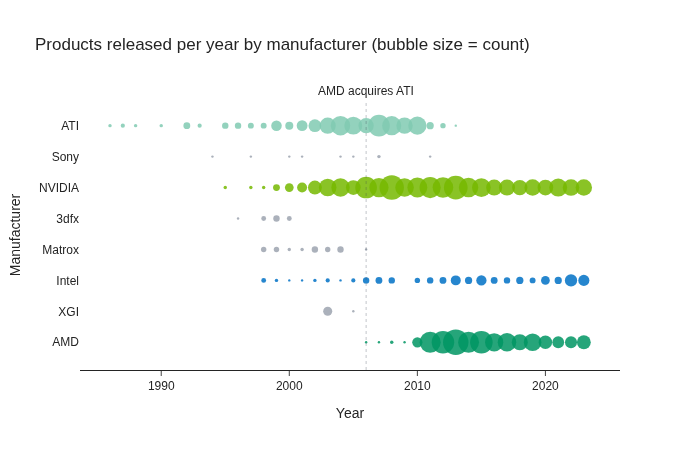

In [23]:
df_vendor_year = df.groupby(['manufacturer', 'releaseYear'], as_index=False).agg({
    'productName': 'count'
}).rename(columns={
    'productName': 'count'
})

vendor_colors = {
    'NVIDIA': '#76b900',
    'AMD': '#009563',
    'ATI': '#80CAB1',
    'Intel': '#0071C5',
    '3dfx': '#9CA3AF',
    'Matrox': '#9CA3AF',
    'Sony': '#9CA3AF',
    'XGI': '#9CA3AF',
}

fig = px.scatter(
    df_vendor_year,
    x='releaseYear',
    y='manufacturer',
    size='count',
    color='manufacturer',
    color_discrete_map=vendor_colors,
    category_orders={
        'manufacturer': list(df_vendor_span['manufacturer'])
    },
    labels={
        'releaseYear': 'Year',
        'manufacturer': 'Manufacturer',
        'count': 'Number of products',
    },
    title='Products released per year by manufacturer (bubble size = count)',
    size_max=18,
    height=450,
)

fig.update_traces(marker={'line_width': 0, 'opacity': 0.85})
fig.update_layout(showlegend=False)
fig.update_yaxes(showline=False, ticks='')
fig.add_vline(
    x=2006,
    line_dash='dot',
    line_color='#374151',
    line_width=1,
    annotation_text='AMD acquires ATI',
    annotation_position='top',
)

fig.show()

In [24]:
# Count a manufacturer as active in a year if it released at least one product that year.
# ATI products released after the 2006 acquisition are counted under AMD.
df_company = df.copy()
df_company['company'] = df_company['manufacturer'].mask(
    (df_company['manufacturer'] == 'ATI') & (df_company['releaseYear'] >= 2006), 'AMD'
)
num_active_companies = df_company.groupby('releaseYear')['company'].nunique()

print(f'Most active manufacturers in one year: {num_active_companies.max()} '
      f'(in {list(num_active_companies[num_active_companies == num_active_companies.max()].index)})')
print(f'Active manufacturers by year, 2010–2023: {num_active_companies.loc[2010:].to_dict()}')

Most active manufacturers in one year: 6 (in [2000])
Active manufacturers by year, 2010–2023: {2010: 3, 2011: 4, 2012: 3, 2013: 3, 2014: 3, 2015: 3, 2016: 3, 2017: 3, 2018: 3, 2019: 3, 2020: 3, 2021: 3, 2022: 3, 2023: 3}


- In 2000, six manufacturers in the dataset released at least one product. Since 2012, every year has had exactly three: **NVIDIA, AMD, and Intel**. (2011 has four because of Sony's PlayStation Vita GPU.)
- Exits: **3dfx** released its last product in 2000 (NVIDIA bought 3dfx's assets at the end of that year), **XGI** appears only in 2003–2005, and **Matrox** last appears in 2006.
- **ATI** products continue to appear until 2013 because the ATI brand outlived the 2006 acquisition.
- This count reflects the dataset's coverage of eight manufacturers. The real market of the late 1990s had more players (S3, 3Dlabs, PowerVR, and others), so the actual consolidation was even larger than shown here.


## 🔍 Shader Counts Over Time (First Pass with v7)

How has the number of unified shaders grown? The next three charts are the author's first look at `unifiedShader` against `releaseYear` for products released since 2010, using the v7 file.

> ⚠️ **Read these charts with caution.** The data integrity check below shows that in v7 the spec columns (including `unifiedShader`) are not attached to the correct products. These charts are kept here as the "before" picture.


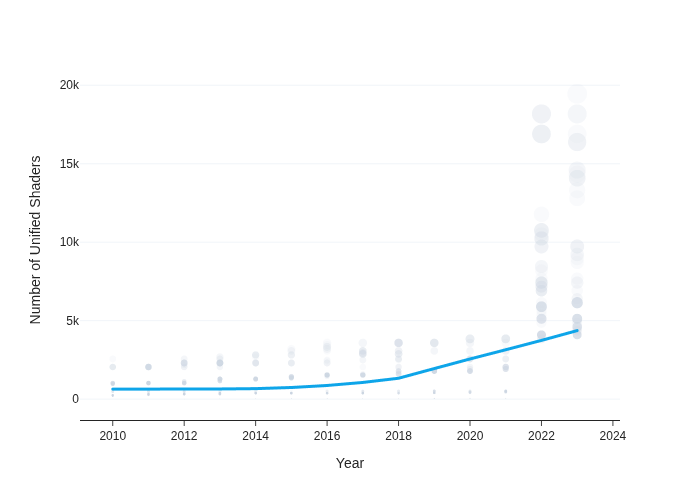

In [25]:
df_p2010 = df.query('releaseYear >= 2010')
df_p2010 = df_p2010.dropna(subset=['unifiedShader'])

fig = px.scatter(
    df_p2010,
    x='releaseYear',
    y='unifiedShader',
    size='unifiedShader',
    trendline="lowess",
    labels={
        'unifiedShader': 'Number of Unified Shaders',
        'releaseYear': 'Year',
    },
    hover_name='productName',
    height=500,
)

# fig.update_layout(yaxis_title='Number of Unified Shaders')
fig.update_yaxes(showline=False, showgrid=True, gridcolor='#F1F5F9', ticks='')
fig.update_traces(
    marker={
        'color': '#CBD5E1',
        'opacity': 0.1,
        'line_width': 0,
    },
    line={
        'color': '#0EA5E9',
        'width': 3,
    }
)

fig.show()

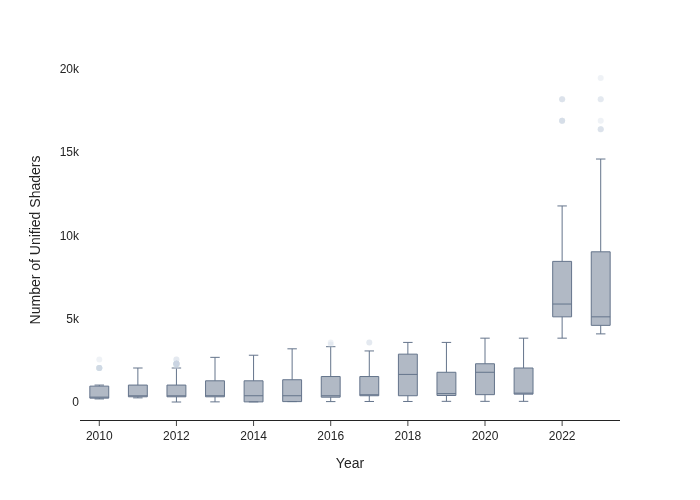

In [26]:
df_p2010 = df.query('releaseYear >= 2010')
df_p2010 = df_p2010.dropna(subset=['unifiedShader'])

fig = px.box(
    df_p2010,
    x='releaseYear',
    y='unifiedShader',
    labels={
        'unifiedShader': 'Number of Unified Shaders',
        'releaseYear': 'Year',
    },
    height=500,
)

fig.update_xaxes(
    # showline=False,
)
fig.update_yaxes(
    showline=False,
    ticks='',
)

fig.update_traces(
    marker={
        'color': '#CBD5E1',
        'opacity': 0.3,
        'line_width': 0,
    },
    line={
        'color': '#64748B',
        'width': 1,
    }
)

fig.show()

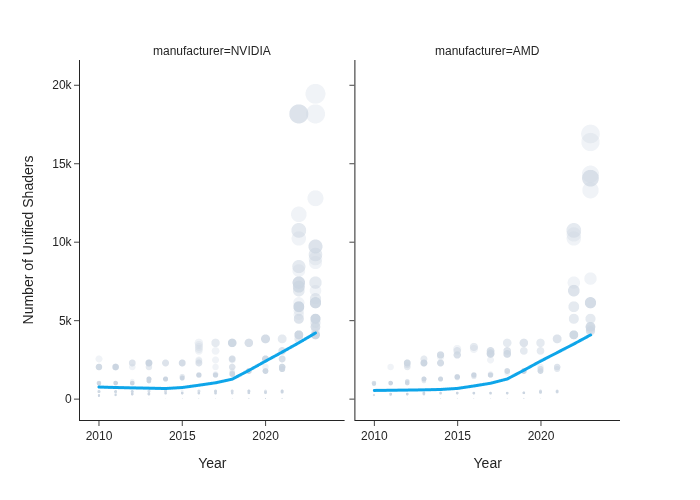

In [27]:
df_p2010_2 = df.query('releaseYear >= 2010')
df_p2010_2 = df_p2010_2[df_p2010_2['manufacturer'].isin(['AMD', 'NVIDIA'])]
df_p2010_2 = df_p2010_2.dropna(subset=['unifiedShader'])

fig = px.scatter(
    df_p2010_2,
    x='releaseYear',
    y='unifiedShader',
    size='unifiedShader',
    facet_col='manufacturer',
    trendline="lowess",
    labels={
        'unifiedShader': 'Number of Unified Shaders',
        'releaseYear': 'Year',
    },
    hover_name='productName',
    height=500,
)

# fig.update_layout(yaxis_title='Number of Unified Shaders')
fig.update_traces(
    marker={
        'color': '#CBD5E1',
        'opacity': 0.3,
        'line_width': 0,
    },
    line={
        'color': '#0EA5E9',
        'width': 3,
    }
)

fig.show()

At first glance, the v7 charts suggest that shader counts were roughly flat from 2010 to about 2016, rose slowly, and then jumped after 2021. That shape is suspicious, because shader counts in GPU generations grew steadily through the 2010s. The next section checks whether the spec columns belong to the products they are listed with.


## ⚠️ Data Integrity Check: Do the Spec Columns Belong to the Right Product?

Start with a few well-known graphics cards whose specs are easy to verify.


In [28]:
famous_cards = ['Radeon 9700 PRO', 'GeForce 8800 GTX', 'Radeon HD 4870', 'GeForce GTX 1080', 'GeForce RTX 3080 Ti']
spec_cols = ['gpuChip', 'unifiedShader', 'pixelShader', 'igp', 'bus', 'memType']

df.query('productName in @famous_cards')[['productName', 'releaseYear', 'memSize'] + spec_cols]

,productName,releaseYear,memSize,gpuChip,unifiedShader,pixelShader,igp,bus,memType
236,GeForce RTX 3080 Ti,2021,12.000,GP104,2560.0,NaN,No,PCIe 3.0 x16,GDDR5X
741,GeForce GTX 1080,2016,8.000,Antilles,1536.0,NaN,No,PCIe 2.0 x16,GDDR5
1970,Radeon HD 4870,2008,0.512,Emerald,896.0,NaN,No,PCIe 3.0 x16,GDDR5
2282,GeForce 8800 GTX,2006,0.768,GP104,2048.0,NaN,No,MXM-B (3.0),GDDR5
2761,Radeon 9700 PRO,2002,0.128,Cezanne,512.0,NaN,Yes,IGP,NaN


In v7, the product names, release years, and memory sizes are right. The spec columns are wrong:

- The **GeForce 8800 GTX** (2006) is listed with a **GP104** chip (NVIDIA's 2016 Pascal chip), 2,048 unified shaders, an MXM mobile module, and GDDR5 memory. The actual card used the G80 chip with 128 unified shaders, PCIe 1.0 x16, and GDDR3.
- The **Radeon 9700 PRO** (2002, an AGP-era discrete card) is listed as an **integrated GPU** with AMD's 2021 "Cezanne" APU graphics.
- The **GeForce RTX 3080 Ti** (2021) carries what look like the GeForce GTX 1080's specs: GP104, 2,560 shaders, PCIe 3.0, and GDDR5X.

The previous version of the same Kaggle dataset (`gpu_specs_v6.csv`) is a useful reference. Load it and look at the same cards.


In [29]:
df_v6 = pd.read_csv('gpu_specs_v6.csv')

df_v6.query('productName in @famous_cards')[['productName', 'releaseYear', 'memSize'] + spec_cols]

,productName,releaseYear,memSize,gpuChip,unifiedShader,pixelShader,igp,bus,memType
88,GeForce RTX 3080 Ti,2021.0,12.000,GA102,10240.0,NaN,No,PCIe 4.0 x16,GDDR6X
560,GeForce GTX 1080,2016.0,8.000,GP104,2560.0,NaN,No,PCIe 3.0 x16,GDDR5X
1951,Radeon HD 4870,2008.0,0.512,RV770,800.0,NaN,No,PCIe 2.0 x16,GDDR5
2158,GeForce 8800 GTX,2006.0,0.768,G80,128.0,NaN,No,PCIe 1.0 x16,GDDR3
2654,Radeon 9700 PRO,2002.0,0.128,R300,NaN,8.0,No,AGP 8x,DDR


In v6, all five cards show their correct chips and specs: R300 on AGP 8x for the 9700 PRO, G80 for the 8800 GTX, RV770 with GDDR5 for the HD 4870, GP104 with GDDR5X for the GTX 1080, and GA102 with GDDR6X for the RTX 3080 Ti.

Spot checks are anecdotal. Next, look for combinations that should never happen in either file.


In [30]:
def run_sanity_checks(data):
    return pd.Series({
        'PCIe bus on a product released before 2004': (
            (data['releaseYear'] < 2004) & data['bus'].str.startswith('PCIe')
        ).sum(),
        'Unified shaders on a product released before 2005': (
            (data['releaseYear'] < 2005) & data['unifiedShader'].notna()
        ).sum(),
        'Separate pixel shaders on a product released in 2015 or later': (
            (data['releaseYear'] >= 2015) & data['pixelShader'].notna()
        ).sum(),
        'Integrated GPU (igp = Yes) with its own memory size': (
            (data['igp'] == 'Yes') & data['memSize'].notna()
        ).sum(),
        'Discrete GPU (igp = No) with no memory size': (
            (data['igp'] == 'No') & data['memSize'].isna()
        ).sum(),
    })


pd.DataFrame({
    'v7 (latest)': run_sanity_checks(df),
    'v6 (previous)': run_sanity_checks(df_v6),
})

,v7 (latest),v6 (previous)
PCIe bus on a product released before 2004,197,2
Unified shaders on a product released before 2005,313,0
Separate pixel shaders on a product released in 2015 or later,171,0
Integrated GPU (igp = Yes) with its own memory size,438,0
Discrete GPU (igp = No) with no memory size,439,0


v7 has hundreds of impossible combinations. v6 has almost none:

- PCI Express graphics cards first shipped in 2004. Yet v7 lists **197** pre-2004 products (some from the 1980s) with a PCIe bus.
- v7 has **313** unified-shader products from before 2005, earlier than any unified-shader GPU existed.
- v7 has **438** integrated GPUs with a dedicated memory size and **439** discrete GPUs without one. In v6, the `igp` flag and the missing `memSize` match perfectly.
- The two v6 exceptions are borderline cases: the GeForce PCX 5900 (dated 2003) and the Matrox Millennium G550 PCIe (dated 2001).

The checks point to a misalignment. In v7, the left-hand columns (`manufacturer`, `productName`, `releaseYear`, `memSize`, `memBusWidth`) describe one product, while the right-hand spec columns (`gpuClock` through `gpuChip`, including `igp`) describe a different one. One more clue comes from the row order:


In [31]:
def share_non_increasing_within_year(data):
    # Within each release year, in file order, how often is the next row's unifiedShader <= the current row's?
    data = data.dropna(subset=['releaseYear', 'unifiedShader'])
    diffs = data.groupby('releaseYear')['unifiedShader'].diff().dropna()
    return (diffs <= 0).mean()


print(f'v7: {share_non_increasing_within_year(df):.1%} of consecutive rows within a year have non-increasing unifiedShader')
print(f'v6: {share_non_increasing_within_year(df_v6):.1%} of consecutive rows within a year have non-increasing unifiedShader')

v7: 100.0% of consecutive rows within a year have non-increasing unifiedShader
v6: 63.2% of consecutive rows within a year have non-increasing unifiedShader


Within every release year in v7, `unifiedShader` never increases from one row to the next (100.0% of consecutive pairs), so the spec rows are perfectly sorted by shader count in descending order. v6 shows no such pattern (63.2%). This is consistent with the spec columns having been sorted separately from the product columns at some point when v7 was produced.

To measure the damage, match products that appear exactly once in both files and check how often each column agrees. As a baseline, compute the agreement you would expect if the column's values were paired with products at random.


In [32]:
key_cols = ['manufacturer', 'productName', 'releaseYear']
compare_cols = ['memSize', 'gpuChip', 'gpuClock', 'memClock', 'unifiedShader', 'tmu', 'rop', 'bus', 'igp']

# Keep products that appear exactly once in each file so that the match is unambiguous
df_v7_unique = df.drop_duplicates(subset=key_cols, keep=False)
df_v6_unique = df_v6.dropna(subset=['releaseYear']) \
    .drop_duplicates(subset=key_cols, keep=False) \
    .astype({'releaseYear': int})

df_matched = df_v7_unique.merge(df_v6_unique, on=key_cols, suffixes=('_v7', '_v6'))
print(f'{df_matched.shape[0]:,} products appear exactly once in both files.')


def chance_agreement(a, b):
    # Agreement expected if the column's values were paired with products at random
    a = a.astype(object).where(a.notna(), 'missing').astype(str)
    b = b.astype(object).where(b.notna(), 'missing').astype(str)
    p_a = a.value_counts(normalize=True)
    p_b = b.value_counts(normalize=True)
    return (p_a * p_b.reindex(p_a.index, fill_value=0)).sum()


agreement_rows = []
for col in compare_cols:
    v7_values = df_matched[f'{col}_v7']
    v6_values = df_matched[f'{col}_v6']
    agreement_rows.append({
        'column': col,
        'matches_v6': ((v7_values == v6_values) | (v7_values.isna() & v6_values.isna())).mean(),
        'expected_by_chance': chance_agreement(v7_values, v6_values),
    })

df_agreement = pd.DataFrame(agreement_rows).sort_values('matches_v6')
df_agreement.assign(
    matches_v6=lambda d: (d['matches_v6'] * 100).round(1),
    expected_by_chance=lambda d: (d['expected_by_chance'] * 100).round(1),
).rename(columns={'matches_v6': 'matches_v6 (%)', 'expected_by_chance': 'expected_by_chance (%)'})

2,412 products appear exactly once in both files.


,column,matches_v6 (%),expected_by_chance (%)
1,gpuChip,1.1,0.5
2,gpuClock,1.6,1.4
3,memClock,3.7,3.7
5,tmu,10.4,6.5
4,unifiedShader,12.9,8.6
7,bus,18.0,10.9
6,rop,28.0,13.6
8,igp,74.5,77.7
0,memSize,99.9,8.2


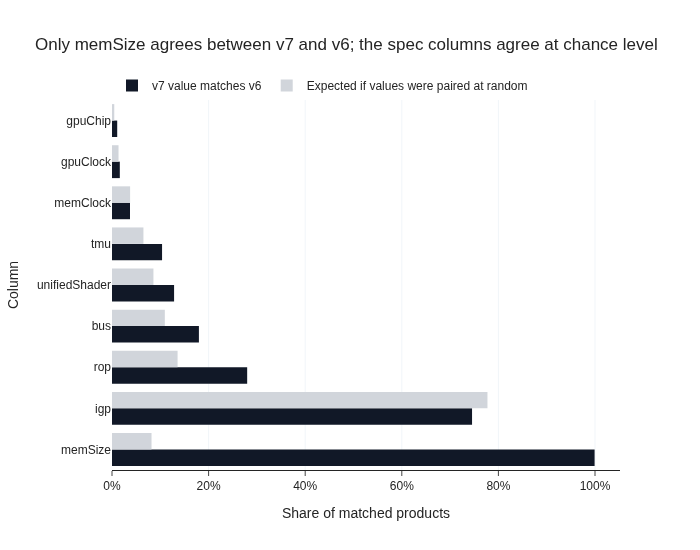

In [33]:
df_plot = df_agreement.melt(
    id_vars='column',
    value_vars=['matches_v6', 'expected_by_chance'],
    var_name='measure',
    value_name='share',
).replace({
    'measure': {
        'matches_v6': 'v7 value matches v6',
        'expected_by_chance': 'Expected if values were paired at random',
    }
})

fig = px.bar(
    df_plot,
    x='share',
    y='column',
    color='measure',
    barmode='group',
    orientation='h',
    color_discrete_map={
        'v7 value matches v6': '#111827',
        'Expected if values were paired at random': '#D1D5DB',
    },
    category_orders={'column': list(df_agreement['column'])},
    labels={
        'share': 'Share of matched products',
        'column': 'Column',
        'measure': '',
    },
    title='Only memSize agrees between v7 and v6; the spec columns agree at chance level',
    height=550,
)

fig.update_xaxes(tickformat='.0%', showgrid=True, gridcolor='#F1F5F9')
fig.update_yaxes(showline=False, ticks='')
fig.update_traces(marker_line_width=0)
fig.update_layout(legend=dict(orientation='h', yanchor='bottom', y=1.0, xanchor='left', x=0))

fig.show()

- **`memSize` matches v6 for 99.9% of the 2,412 matched products**, compared with 8.2% expected by chance. The product-identity columns are intact.
- **Every spec column matches at roughly chance level.** `gpuChip` matches 1.1% of the time (0.5% by chance) and `gpuClock` 1.6% (1.4%). `igp` matches 74.5% of the time, but only because most products are discrete; random pairing would produce 77.7%.
- Columns that track the era, such as `tmu`, `unifiedShader`, `bus`, and `rop`, match a little more often than chance. The shuffled spec rows seem to have stayed loosely near their original time period, which is why the v7 charts still slope upward and look plausible.


v6 (previous): median shader count doubles every 2.8 years (2008–2022)
v7 (latest, scrambled specs): median shader count doubles every 5.3 years (2008–2022)


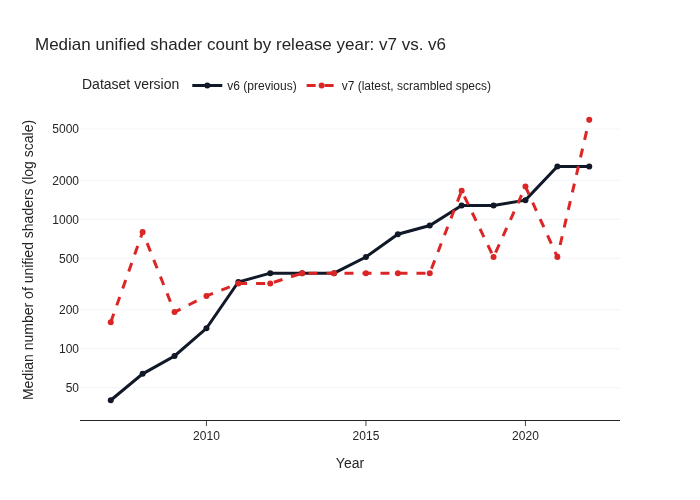

In [34]:
df_shader_compare = pd.concat([
    df.assign(version='v7 (latest, scrambled specs)'),
    df_v6.assign(version='v6 (previous)'),
]).dropna(subset=['unifiedShader']) \
  .query('releaseYear >= 2007 and releaseYear <= 2022') \
  .groupby(['version', 'releaseYear'], as_index=False) \
  .agg({'unifiedShader': 'median'})

for version, df_version in df_shader_compare.query('releaseYear >= 2008').groupby('version'):
    slope = np.polyfit(df_version['releaseYear'], np.log2(df_version['unifiedShader']), deg=1)[0]
    print(f'{version}: median shader count doubles every {1 / slope:.1f} years (2008–2022)')

fig = px.line(
    df_shader_compare,
    x='releaseYear',
    y='unifiedShader',
    color='version',
    line_dash='version',
    log_y=True,
    markers=True,
    color_discrete_map={
        'v6 (previous)': '#111827',
        'v7 (latest, scrambled specs)': '#DC2626',
    },
    line_dash_map={
        'v6 (previous)': 'solid',
        'v7 (latest, scrambled specs)': 'dash',
    },
    labels={
        'releaseYear': 'Year',
        'unifiedShader': 'Median number of unified shaders (log scale)',
        'version': 'Dataset version',
    },
    title='Median unified shader count by release year: v7 vs. v6',
    height=500,
)

fig.update_traces(line_width=3, marker_size=6)
fig.update_yaxes(
    showline=False,
    showgrid=True,
    gridcolor='#F1F5F9',
    ticks='',
    tickvals=[50, 100, 200, 500, 1000, 2000, 5000],
)
fig.update_layout(legend=dict(orientation='h', yanchor='bottom', y=1.0, xanchor='left', x=0))

fig.show()

The scrambling changes the conclusions, not just a few rows:

- In v6, the median shader count **doubles about every 2.8 years** (2008–2022). In v7 the trend is noisy and the implied doubling time is **5.3 years**.
- v7 shows the median stuck at 384 shaders from 2013 to 2017. In v6 it more than doubles over the same period, from 384 to 896.
- v7 also puts a median of 800 shaders in 2008, more than ten times v6's 64.

### ✅ Decision: which file to use for what

| Columns | Source | Why |
|---|---|---|
| `manufacturer`, `productName`, `releaseYear`, `memSize` | **v7** (through 2023) | Intact (99.9% agreement with v6) and more complete for 2022–2023 |
| `unifiedShader`, `pixelShader`, `memType`, `bus`, `igp`, `gpuChip`, clocks | **v6** (1995–2022) | v7's values belong to other products |

Note that v6 is also incomplete for 2022. It has 57 products for that year compared with 98 in v7, and a few of its 2022 rows are pre-launch placeholders (for example, a "GeForce RTX 4080 Ti" with 20 GB that never shipped). The spec analysis below uses shares within each year, so partial coverage in 2022 matters less, but read 2022 with care.


In [35]:
df_specs = df_v6.query('releaseYear >= 1995 and releaseYear <= 2022').copy()
df_specs['releaseYear'] = df_specs['releaseYear'].astype(int)

print(f'{df_specs.shape[0]:,} products released 1995–2022 in v6')
print(f"{(df_specs['igp'] == 'No').sum():,} of them are discrete GPUs")

2,823 products released 1995–2022 in v6
2,411 of them are discrete GPUs


## 🧬 When Did Unified Shaders Replace Separate Pixel/Vertex Shaders?

Older GPUs had separate units for vertex and pixel processing (or fixed-function pipelines). Unified shader architectures, which arrived with the DirectX 10 generation, use one pool of programmable shaders for both. In the data, a product has either a `unifiedShader` count or `pixelShader`/`vertexShader` counts. Using the v6 spec columns:

In [36]:
df_specs['shaderArchitecture'] = np.where(
    df_specs['unifiedShader'].notna(),
    'Unified shaders',
    'Separate pixel/vertex shaders',
)

df_arch = df_specs.query('releaseYear >= 1998 and releaseYear <= 2012') \
    .groupby(['releaseYear', 'shaderArchitecture'], as_index=False) \
    .agg({'productName': 'count'}) \
    .rename(columns={'productName': 'count'})
df_arch['share'] = df_arch['count'] / df_arch.groupby('releaseYear')['count'].transform('sum')

df_arch.query('releaseYear >= 2005 and releaseYear <= 2010') \
    .pivot(index='shaderArchitecture', columns='releaseYear', values='count') \
    .fillna(0) \
    .astype(int)

releaseYear,2005,2006,2007,2008,2009,2010
shaderArchitecture,,,,,,
Separate pixel/vertex shaders,96,127,62,9,0,2
Unified shaders,1,2,94,165,106,146


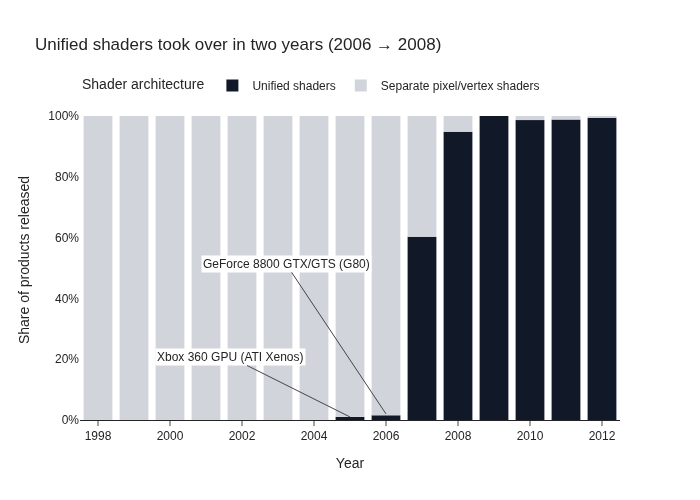

In [37]:
fig = px.bar(
    df_arch,
    x='releaseYear',
    y='share',
    color='shaderArchitecture',
    color_discrete_map={
        'Unified shaders': '#111827',
        'Separate pixel/vertex shaders': '#D1D5DB',
    },
    category_orders={
        'shaderArchitecture': ['Unified shaders', 'Separate pixel/vertex shaders']
    },
    labels={
        'releaseYear': 'Year',
        'share': 'Share of products released',
        'shaderArchitecture': 'Shader architecture',
    },
    title='Unified shaders took over in two years (2006 → 2008)',
    height=500,
)

fig.update_traces(marker_line_width=0)
fig.update_yaxes(showline=False, tickformat='.0%', ticks='')
fig.update_layout(legend=dict(orientation='h', yanchor='bottom', y=1.0, xanchor='left', x=0))
fig.add_annotation(
    x=2006,
    y=0.02,
    text='GeForce 8800 GTX/GTS (G80)',
    showarrow=True,
    arrowhead=0,
    ax=-100,
    ay=-150,
    bgcolor='white',
    font={'size': 12},
)
fig.add_annotation(
    x=2005,
    y=0.01,
    text='Xbox 360 GPU (ATI Xenos)',
    showarrow=True,
    arrowhead=0,
    ax=-120,
    ay=-60,
    bgcolor='white',
    font={'size': 12},
)

fig.show()

In [38]:
df_specs.query('shaderArchitecture == "Unified shaders"') \
    .nsmallest(5, 'releaseYear')[['manufacturer', 'productName', 'releaseYear', 'unifiedShader', 'gpuChip']]

,manufacturer,productName,releaseYear,unifiedShader,gpuChip
2340,ATI,Xbox 360 GPU 90nm,2005,240.0,Xenos Xenon
2157,NVIDIA,GeForce 8800 GTS 640,2006,96.0,G80
2158,NVIDIA,GeForce 8800 GTX,2006,128.0,G80
1960,ATI,FireGL V3600,2007,120.0,RV630
1961,ATI,FireGL V5600,2007,120.0,RV630


In [39]:
df_specs.query('releaseYear >= 2009 and shaderArchitecture == "Separate pixel/vertex shaders"')[
    ['manufacturer', 'productName', 'releaseYear', 'pixelShader', 'vertexShader']
]

,manufacturer,productName,releaseYear,pixelShader,vertexShader
1054,NVIDIA,Playstation 3 GPU 28nm,2013,24.0,8.0
1173,NVIDIA,Tegra 4 GPU,2013,48.0,24.0
1174,NVIDIA,Tegra 4i GPU,2013,48.0,12.0
1271,NVIDIA,Playstation 3 GPU 40nm,2012,24.0,8.0
1428,Sony,Playstation Vita GPU,2011,4.0,2.0
1518,NVIDIA,Tegra 3 GPU,2011,8.0,4.0
1605,Intel,GMA,2010,4.0,2.0
1677,NVIDIA,Tegra 2 GPU,2010,4.0,4.0


- **The switch to unified shaders took about two years.** In 2006 only 2 of 129 products (1.6%) had unified shaders. In 2007 it was 94 of 156 (60%), in 2008 165 of 174 (95%), and in 2009 every product.
- **A game console came first.** The earliest unified-shader GPU in the data is the **Xbox 360 GPU** (ATI's Xenos, 2005). The first PC cards were NVIDIA's GeForce 8800 GTX/GTS (G80) in 2006.
- **The holdouts after 2009 are all mobile or console chips**: NVIDIA Tegra 2/3/4, die-shrunk PlayStation 3 GPUs, the PlayStation Vita GPU, and one Intel GMA part.


## 💾 How Fast Has Graphics Memory Grown?

`memSize` (GB) is a product-level column that v7 still gets right (it matched v6 for 99.9% of products), so this section uses v7 through 2023. Integrated GPUs have no memory size of their own (they share system memory), so they drop out here.

In [40]:
import statsmodels.formula.api as smf

df_mem = df.dropna(subset=['memSize']).query('releaseYear >= 1995')

df_mem_year = df_mem.groupby('releaseYear', as_index=False).agg(
    median_mem=('memSize', 'median'),
    max_mem=('memSize', 'max'),
    num_products=('memSize', 'count'),
)
df_mem_year['log2_median_mem'] = np.log2(df_mem_year['median_mem'])
df_mem_year['max_to_median'] = df_mem_year['max_mem'] / df_mem_year['median_mem']

# Product holding the largest memory in each year (for annotations)
df_mem_year['max_product'] = df_mem.loc[
    df_mem.groupby('releaseYear')['memSize'].idxmax(), 'productName'
].values

df_mem_year.query('releaseYear in [2000, 2005, 2010, 2015, 2020, 2023]')

,releaseYear,median_mem,max_mem,num_products,log2_median_mem,max_to_median,max_product
5,2000,0.032,0.128,31,-4.965784,4.000000,Fire GL3
10,2005,0.256,1.024,88,-1.965784,4.000000,FireGL V7350
15,2010,1.024,6.000,133,0.034216,5.859375,Quadro 6000
20,2015,2.000,32.000,135,1.000000,16.000000,FirePro S9170
25,2020,8.000,80.000,68,3.000000,10.000000,A100 SXM4 80 GB
28,2023,12.000,192.000,81,3.584963,16.000000,Radeon Instinct MI300X


In [41]:
# Piecewise log-linear trend: does the doubling time change after 2010?
df_mem_year['post_2010'] = (df_mem_year['releaseYear'] >= 2010).astype(int)
model_mem = smf.ols('log2_median_mem ~ releaseYear * post_2010', data=df_mem_year).fit()

slope_pre = model_mem.params['releaseYear']
slope_post = slope_pre + model_mem.params['releaseYear:post_2010']
print(f'Median memory doubling time, 1995–2009: {1 / slope_pre:.1f} years')
print(f'Median memory doubling time, 2010–2023: {1 / slope_post:.1f} years')
print(f"p-value for the change in slope: {model_mem.pvalues['releaseYear:post_2010']:.1e}")

# Robustness: product-level regression and other break years
df_mem_model = df_mem.assign(
    log2_mem=np.log2(df_mem['memSize']),
    post_2010=(df_mem['releaseYear'] >= 2010).astype(int),
)
model_mem_products = smf.ols('log2_mem ~ releaseYear * post_2010', data=df_mem_model).fit()
slope_pre_p = model_mem_products.params['releaseYear']
slope_post_p = slope_pre_p + model_mem_products.params['releaseYear:post_2010']
print(f'Product-level fit: {1 / slope_pre_p:.1f} years before 2010 vs. {1 / slope_post_p:.1f} years from 2010')

robustness_rows = []
for break_year in range(2006, 2013):
    df_tmp = df_mem_year.assign(post=(df_mem_year['releaseYear'] >= break_year).astype(int))
    m = smf.ols('log2_median_mem ~ releaseYear * post', data=df_tmp).fit()
    s_pre = m.params['releaseYear']
    s_post = s_pre + m.params['releaseYear:post']
    robustness_rows.append({
        'break_year': break_year,
        'doubling_years_before': round(1 / s_pre, 2),
        'doubling_years_after': round(1 / s_post, 2),
    })

pd.DataFrame(robustness_rows).set_index('break_year').T

Median memory doubling time, 1995–2009: 1.7 years
Median memory doubling time, 2010–2023: 3.4 years
p-value for the change in slope: 1.3e-07
Product-level fit: 1.9 years before 2010 vs. 3.3 years from 2010


break_year,2006,2007,2008,2009,2010,2011,2012
doubling_years_before,1.38,1.45,1.55,1.60,1.67,1.70,1.75
doubling_years_after,3.01,3.06,3.21,3.23,3.39,3.32,3.37


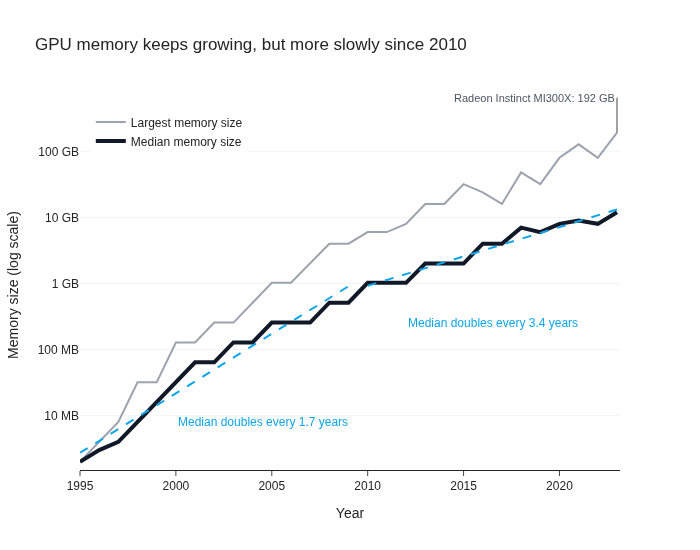

In [42]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_mem_year['releaseYear'],
    y=df_mem_year['max_mem'],
    name='Largest memory size',
    mode='lines',
    line={'color': '#9CA3AF', 'width': 2},
    customdata=df_mem_year['max_product'],
    hovertemplate='%{x}: %{y} GB (%{customdata})<extra></extra>',
))
fig.add_trace(go.Scatter(
    x=df_mem_year['releaseYear'],
    y=df_mem_year['median_mem'],
    name='Median memory size',
    mode='lines',
    line={'color': '#111827', 'width': 4},
    hovertemplate='%{x}: %{y} GB<extra></extra>',
))

# Fitted trend lines for the two eras
for is_post, label in [(0, '1995–2009 trend'), (1, '2010–2023 trend')]:
    df_era_fit = df_mem_year.query('post_2010 == @is_post')
    fig.add_trace(go.Scatter(
        x=df_era_fit['releaseYear'],
        y=2 ** model_mem.predict(df_era_fit),
        name=label,
        mode='lines',
        line={'color': '#0EA5E9', 'width': 2, 'dash': 'dash'},
        showlegend=False,
        hoverinfo='skip',
    ))

fig.add_annotation(x=2000, y=np.log10(0.008), text=f'Median doubles every {1 / slope_pre:.1f} years',
                   showarrow=False, font={'color': '#0EA5E9'}, xanchor='left')
fig.add_annotation(x=2012, y=np.log10(0.25), text=f'Median doubles every {1 / slope_post:.1f} years',
                   showarrow=False, font={'color': '#0EA5E9'}, xanchor='left')
row_max = df_mem_year.iloc[-1]
fig.add_annotation(x=row_max['releaseYear'], y=np.log10(row_max['max_mem']),
                   text=f"{row_max['max_product']}: {row_max['max_mem']:.0f} GB",
                   showarrow=True, arrowhead=0, ax=0, ay=-35, xanchor='right', font={'size': 11, 'color': '#4B5563'})

fig.update_yaxes(
    type='log',
    tickvals=[0.001, 0.01, 0.1, 1, 10, 100],
    ticktext=['1 MB', '10 MB', '100 MB', '1 GB', '10 GB', '100 GB'],
    range=[np.log10(0.0015), np.log10(600)],
    title='Memory size (log scale)',
    showline=False,
    showgrid=True,
    gridcolor='#F1F5F9',
    ticks='',
)
fig.update_xaxes(title='Year')
fig.update_layout(
    title='GPU memory keeps growing, but more slowly since 2010',
    height=550,
    legend=dict(yanchor='top', xanchor='left', y=0.98, x=0.02),
)

fig.show()

- **Median memory grew from 32 MB (2000) to 1 GB (2010) to 12 GB (2023).**
- **Growth slowed after 2010.** The median doubled about every **1.7 years** from 1995 to 2009 and about every **3.4 years** from 2010 to 2023 (the change in slope has p = 1.3e-07). The slowdown does not depend on the 2010 cutoff. With any break year from 2006 to 2012, the doubling time is 1.4–1.8 years before the break and 3.0–3.4 years after. A product-level regression gives a similar result (1.9 vs. 3.3 years).
- **The top of the market has pulled away.** The largest-memory product was 4× the median in 2000 and 2005, but 16× in 2015 and 2023. The maximum has long been set by workstation and data-center products (Fire GL, Quadro, FirePro, A100, and Instinct in the table above). The 2023 maximum is the Radeon Instinct MI300X with 192 GB.
- Caveat: the median is taken over all discrete SKUs, so it partly reflects the product mix each year (for example, how many low-end or mobile parts were released).


## 🔌 Technology Transitions: Memory Types and Bus Interfaces

These two columns come from the v6 spec columns (1995–2022). Integrated GPUs are excluded because they use system memory and an internal bus.

### Memory type

In [43]:
mem_type_groups = {
    'EDO': 'SDR & older', 'FPM': 'SDR & older', 'DRAM': 'SDR & older', 'VRAM': 'SDR & older',
    'SGRAM': 'SDR & older', 'SGR': 'SDR & older', 'CDRAM': 'SDR & older', 'SDR': 'SDR & older',
    'DDR': 'DDR',
    'GDDR2': 'GDDR3 (incl. GDDR2/4)', 'GDDR3': 'GDDR3 (incl. GDDR2/4)', 'GDDR4': 'GDDR3 (incl. GDDR2/4)',
    'GDDR5': 'GDDR5/5X', 'GDDR5X': 'GDDR5/5X',
    'GDDR6': 'GDDR6/6X', 'GDDR6X': 'GDDR6/6X',
    'HBM': 'HBM', 'HBM2': 'HBM', 'HBM2e': 'HBM', 'HBM3': 'HBM',
    'DDR2': 'DDR2–DDR4 (commodity)', 'DDR3': 'DDR2–DDR4 (commodity)', 'DDR4': 'DDR2–DDR4 (commodity)',
}
mem_group_order = ['SDR & older', 'DDR', 'GDDR3 (incl. GDDR2/4)', 'GDDR5/5X', 'GDDR6/6X', 'HBM',
                   'DDR2–DDR4 (commodity)', 'Other']

df_discrete = df_specs.query('igp == "No"').copy()
df_discrete['memGroup'] = df_discrete['memType'].map(mem_type_groups).fillna('Other')

df_mem_type = pd.crosstab(df_discrete['releaseYear'], df_discrete['memGroup'], normalize='index') \
    .reset_index() \
    .melt(id_vars='releaseYear', var_name='memGroup', value_name='share')

# Which memory type was the most common in each year, and for how long did it stay on top?
df_mem_top = df_mem_type.loc[df_mem_type.groupby('releaseYear')['share'].idxmax()]
df_mem_top.groupby('memGroup', as_index=False).agg(
    first_year_on_top=('releaseYear', 'min'),
    last_year_on_top=('releaseYear', 'max'),
    years_on_top=('releaseYear', 'count'),
    peak_share=('share', 'max'),
).sort_values('first_year_on_top').round(2)

,memGroup,first_year_on_top,last_year_on_top,years_on_top,peak_share
4,SDR & older,1995,1999,5,1.00
0,DDR,2000,2004,5,0.90
1,GDDR3 (incl. GDDR2/4),2005,2009,5,0.69
2,GDDR5/5X,2010,2018,9,0.80
3,GDDR6/6X,2019,2022,4,0.92


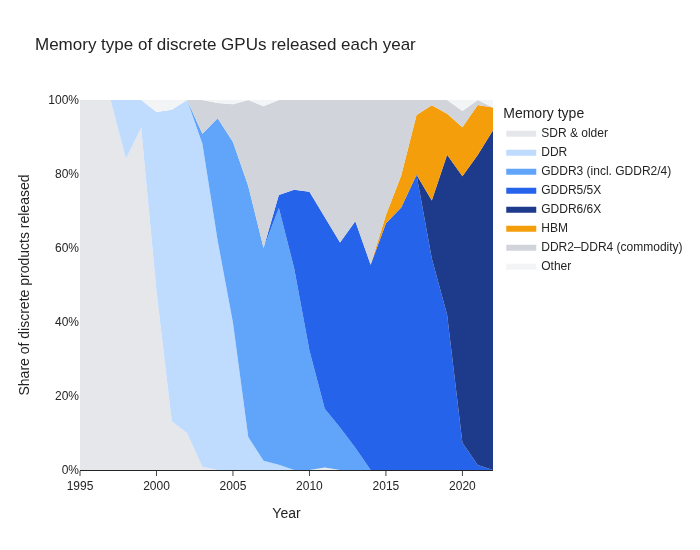

In [44]:
fig = px.area(
    df_mem_type,
    x='releaseYear',
    y='share',
    color='memGroup',
    category_orders={'memGroup': mem_group_order},
    color_discrete_map={
        'SDR & older': '#E5E7EB',
        'DDR': '#BFDBFE',
        'GDDR3 (incl. GDDR2/4)': '#60A5FA',
        'GDDR5/5X': '#2563EB',
        'GDDR6/6X': '#1E3A8A',
        'HBM': '#F59E0B',
        'DDR2–DDR4 (commodity)': '#D1D5DB',
        'Other': '#F3F4F6',
    },
    labels={
        'releaseYear': 'Year',
        'share': 'Share of discrete products released',
        'memGroup': 'Memory type',
    },
    title='Memory type of discrete GPUs released each year',
    height=550,
)

fig.for_each_trace(lambda trace: trace.update(fillcolor=trace.line.color))
fig.update_traces(line={'width': 0})
fig.update_yaxes(showline=False, tickformat='.0%', ticks='')
fig.update_layout(hovermode='x', yaxis_range=[0, 1])

fig.show()

In [45]:
df_hbm = df_discrete.query('memGroup == "HBM"') \
    .groupby('releaseYear', as_index=False) \
    .agg(num_products=('productName', 'count'), example=('productName', 'first'))

df_hbm.merge(df_mem_type.query('memGroup == "HBM"')[['releaseYear', 'share']], on='releaseYear').round(2)

,releaseYear,num_products,example,share
0,2015,3,Radeon R9 FURY,0.02
1,2016,8,FirePro S9300 X2,0.09
2,2017,16,Radeon Instinct MI25,0.16
3,2018,18,Quadro GV100,0.26
4,2019,9,Radeon Pro Vega 48,0.11
5,2020,9,A100 PCIe,0.13
6,2021,10,A100 PCIe 80 GB,0.14
7,2022,3,Arctic Sound-M,0.06


- Each memory generation was the most common type for about five years: **SDR and older** in 1995–1999, **DDR** in 2000–2004 (peak 90%), and **GDDR3** in 2005–2009.
- **GDDR5 was on top for nine years (2010–2018)**, longer than any other memory type, and peaked at 80% of discrete products in 2017. **GDDR6/6X** took over in 2019 and reached 92% in 2022.
- **HBM** (stacked memory) first appeared in 2015 (Radeon R9 FURY) and peaked at 26% of discrete products in 2018 with 18 products. Early HBM products include consumer cards (Radeon R9 FURY, RX Vega 56/64), but after 2019 HBM appears almost only on data-center and workstation parts. It did not replace GDDR in mainstream cards.
- The gray band shows low-end cards that used commodity DDR2/DDR3 memory. It was sizable from about 2006 to 2016 and nearly disappeared after 2017.


### Bus interface

In [46]:
def get_bus_group(bus):
    if bus.startswith('PCIe'):
        return bus.split(' x')[0]  # e.g., 'PCIe 3.0 x16' -> 'PCIe 3.0'
    if bus.startswith('AGP'):
        return 'AGP'
    if bus.startswith('PCI'):
        return 'PCI'
    if bus.startswith('MXM'):
        return 'MXM (mobile module)'
    return 'Other'


bus_group_order = ['PCI', 'AGP', 'PCIe 1.0', 'PCIe 2.0', 'PCIe 3.0', 'PCIe 4.0', 'PCIe 5.0',
                   'MXM (mobile module)', 'Other']

df_discrete['busGroup'] = df_discrete['bus'].map(get_bus_group)

df_bus = pd.crosstab(df_discrete['releaseYear'], df_discrete['busGroup'], normalize='index') \
    .reset_index() \
    .melt(id_vars='releaseYear', var_name='busGroup', value_name='share')

df_bus_top = df_bus.loc[df_bus.groupby('releaseYear')['share'].idxmax()]
df_bus_first = df_discrete.groupby('busGroup', as_index=False).agg(first_year_in_data=('releaseYear', 'min'))

df_bus_top.groupby('busGroup', as_index=False).agg(
    first_year_on_top=('releaseYear', 'min'),
    last_year_on_top=('releaseYear', 'max'),
    years_on_top=('releaseYear', 'count'),
    peak_share=('share', 'max'),
).merge(df_bus_first, on='busGroup').sort_values('first_year_on_top').round(2)

,busGroup,first_year_on_top,last_year_on_top,years_on_top,peak_share,first_year_in_data
1,PCI,1995,1996,2,1.00,1995
0,AGP,1997,2003,7,0.92,1996
2,PCIe 1.0,2004,2007,4,0.79,2001
3,PCIe 2.0,2008,2012,5,0.83,2007
4,PCIe 3.0,2013,2019,7,0.85,2011
5,PCIe 4.0,2020,2022,3,0.88,2018


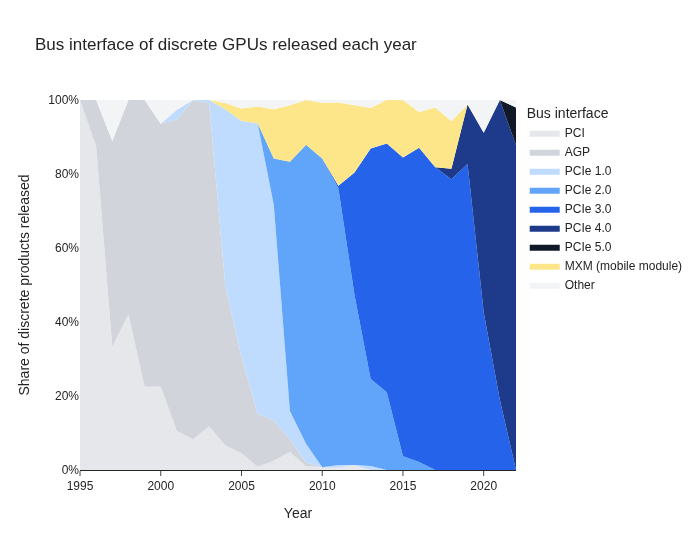

In [47]:
fig = px.area(
    df_bus,
    x='releaseYear',
    y='share',
    color='busGroup',
    category_orders={'busGroup': bus_group_order},
    color_discrete_map={
        'PCI': '#E5E7EB',
        'AGP': '#D1D5DB',
        'PCIe 1.0': '#BFDBFE',
        'PCIe 2.0': '#60A5FA',
        'PCIe 3.0': '#2563EB',
        'PCIe 4.0': '#1E3A8A',
        'PCIe 5.0': '#111827',
        'MXM (mobile module)': '#FDE68A',
        'Other': '#F3F4F6',
    },
    labels={
        'releaseYear': 'Year',
        'share': 'Share of discrete products released',
        'busGroup': 'Bus interface',
    },
    title='Bus interface of discrete GPUs released each year',
    height=550,
)

fig.for_each_trace(lambda trace: trace.update(fillcolor=trace.line.color))
fig.update_traces(line={'width': 0})
fig.update_yaxes(showline=False, tickformat='.0%', ticks='')
fig.update_layout(hovermode='x', yaxis_range=[0, 1])

fig.show()

- **AGP was the main interface for seven years (1997–2003)**, peaking at 92% of discrete products. **PCIe 1.0 overtook it in 2004**, the first year PCIe cards appear in volume.
- PCIe generations then took turns at the top: **PCIe 1.0 for four years (2004–2007), PCIe 2.0 for five years (2008–2012), PCIe 3.0 for seven years (2013–2019), and PCIe 4.0 from 2020**. PCIe 3.0's run was the longest of any PCIe generation, much like GDDR5's run among memory types.
- Each new PCIe generation took one to two years to go from its first appearance to the top (PCIe 2.0: 2007 → 2008, PCIe 3.0: 2011 → 2013, PCIe 4.0: 2018 → 2020). The first PCIe 5.0 products appear in 2022. (PCIe 1.0's first appearance in 2001 is the Matrox outlier mentioned earlier.)
- The yellow band is **MXM**, a module format for laptop GPUs. It was common from 2007 to 2018. In later years, mobile GPUs are listed with PCIe buses.


## 💻 Integrated vs. Discrete GPUs

Integrated GPUs (IGPs) live inside a CPU or chipset and share system memory. Using the v6 `igp` flag (1995–2022):

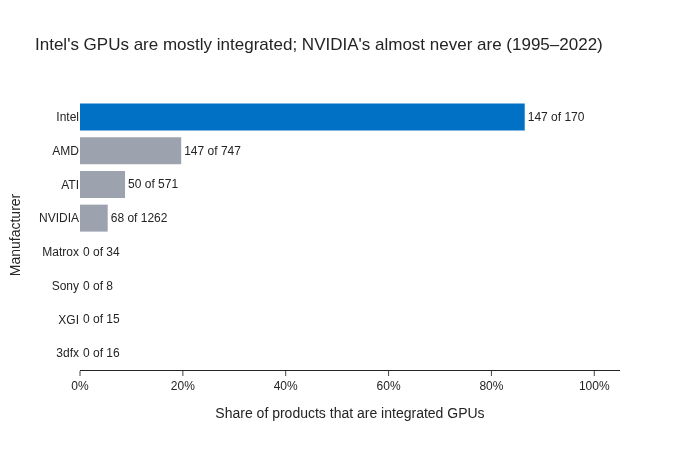

In [48]:
df_specs['isIntegrated'] = df_specs['igp'] == 'Yes'

df_igp = df_specs.groupby('manufacturer', as_index=False).agg(
    num_products=('productName', 'count'),
    num_integrated=('isIntegrated', 'sum'),
    share_integrated=('isIntegrated', 'mean'),
).sort_values('share_integrated')

fig = px.bar(
    df_igp,
    x='share_integrated',
    y='manufacturer',
    orientation='h',
    text=df_igp.apply(lambda row: f"{row['num_integrated']} of {row['num_products']}", axis=1),
    labels={
        'share_integrated': 'Share of products that are integrated GPUs',
        'manufacturer': 'Manufacturer',
    },
    title="Intel's GPUs are mostly integrated; NVIDIA's almost never are (1995–2022)",
    height=450,
)

fig.update_traces(
    marker_color=['#0071C5' if m == 'Intel' else '#9CA3AF' for m in df_igp['manufacturer']],
    marker_line_width=0,
    textposition='outside',
    cliponaxis=False,
)
fig.update_xaxes(tickformat='.0%', range=[0, 1.05])
fig.update_yaxes(showline=False, ticks='')

fig.show()

In [49]:
df_specs.query('manufacturer == "Intel" and igp == "No"') \
    .groupby('releaseYear', as_index=False) \
    .agg(
        num_products=('productName', 'count'),
        example_products=('productName', lambda names: ', '.join(names.head(3))),
    )

,releaseYear,num_products,example_products
0,1998,2,"i740, i740 8 MB"
1,1999,1,i752
2,2010,1,Aubrey Isle
3,2012,3,"Xeon Phi 3120A, Xeon Phi 5110P, Xeon Phi SE10X"
4,2013,3,"Xeon Phi 5120D, Xeon Phi 7120P, Xeon Phi 7120X"
5,2020,2,"H3C XG310, Iris Xe MAX Graphics"
6,2021,2,"Arctic Sound 1T, Arctic Sound 2T"
7,2022,9,"Arc A350M, Arc A370M, Arc A380"


In [50]:
# Intel's recent releases in v7 (memSize is reliable in v7; integrated GPUs have no memory size)
df_intel_recent = df.query('manufacturer == "Intel" and releaseYear >= 2021')

print(f'Intel products released 2021–2023: {df_intel_recent.shape[0]}')
print(f"  with dedicated memory (discrete): {df_intel_recent['memSize'].notna().sum()}")
print(f"  without dedicated memory (integrated): {df_intel_recent['memSize'].isna().sum()}")

Intel products released 2021–2023: 56
  with dedicated memory (discrete): 28
  without dedicated memory (integrated): 28


- **Intel's GPUs are mostly integrated: 147 of 170 products (86%) from 1995–2022.** AMD's are about 20% integrated (147 of 747, mostly APUs). NVIDIA's are 5% integrated (68 of 1,262: chipset graphics and Tegra). Matrox, 3dfx, XGI, and Sony have no integrated products in the data.
- **Intel's discrete GPU history comes in short bursts:** the i740/i752 AGP cards (1998–1999), the Knights Ferry ("Aubrey Isle") and Xeon Phi compute cards (2010–2013; these are accelerators rather than graphics cards), DG1 / Iris Xe MAX (2020), Arctic Sound (2021), and finally **9 Arc products in 2022**. In v7, Intel's 2021–2023 releases are split evenly between discrete products (Arc and Data Center GPUs) and integrated parts (see the count above). The discrete launches drive Intel's jump to 19.6% of product releases in that period.
- Product counts understate Intel's real-world presence. Intel ships integrated graphics in a huge number of PCs, but each integrated GPU appears here as a single SKU.


## Key Findings

- **The latest dataset version (v7) is scrambled.** Product names, years, and memory sizes are correct (`memSize` matches v6 for 99.9% of 2,412 products), but every spec column (chip, shaders, clocks, bus, memory type, `igp`) matches v6 only at chance level (e.g., `gpuChip` 1.1% vs. 0.5% by chance). v7 lists 197 pre-2004 products with a PCIe bus and 313 pre-2005 products with unified shaders. Within each year, its spec rows are perfectly sorted by shader count. Charts built on v7's specs look plausible but are wrong: v7 implies a 5.3-year doubling time for median shader count, compared with 2.8 years in the correct data.
- **The vendor field shrank to three companies.** In 2000, six manufacturers in the dataset released products. Since 2012 there have been exactly three: NVIDIA, AMD, and Intel. Since 2000, NVIDIA and AMD + ATI have each released roughly 42%–52% of products in every era, until Intel's Arc launches lifted its share to 19.6% in 2021–2023.
- **Unified shaders replaced separate pixel/vertex shaders in about two years**, from 1.6% of products in 2006 to 95% in 2008 and 100% in 2009. The first unified design in the data is a console GPU (Xbox 360, 2005).
- **Growth in graphics memory has slowed.** The median doubled every 1.7 years in 1995–2009 and every 3.4 years in 2010–2023 (p = 1.3e-07), and the result holds for any break year from 2006 to 2012. The largest-memory product went from 4× the median (2000) to 16× (2023, the 192 GB Instinct MI300X).
- **Each technology generation has a typical lifespan.** Memory types stayed on top for about five years each, except GDDR5, which lasted nine (2010–2018). Bus interfaces show a similar pattern: AGP lasted seven years and PCIe 3.0 lasted seven (2013–2019).
- **Integrated graphics is mostly an Intel story.** 86% of Intel's products are integrated, compared with 20% for AMD and 5% for NVIDIA.


## Case Study Potential

**Verdict: Strong.** The dataset combines two good teaching hooks. The first is a realistic, discoverable **data-integrity failure**: the newest version of a popular CC0 Kaggle dataset has its spec columns silently misaligned, and the charts built on it look believable. The second is a clean history of **technology adoption and market consolidation** once the correct version is used. Students practice skepticism, reconciliation of data versions, and time-series storytelling on a topic they already know something about.

**Suggested framing:** *You are an analyst at a PC hardware review site (or a GPU market-research firm). Your editor wants a "40 years of GPUs" feature built on the latest Kaggle dataset. Before publishing, you need to decide which charts you can stand behind.* Part 1: profile the data and catch the problem. Part 2: reconcile v6 and v7 and choose a source for each column. Part 3: tell the history (consolidation, unified shaders, memory growth, bus and memory generations).

**Analytics skills exercised:** data profiling and sanity checks (domain rules), joining two data versions on a composite key with duplicates, column-level agreement against a chance baseline, `groupby`/`crosstab` share-over-time analysis, log-scale growth and doubling-time regression with a structural break (interaction term, robustness to break year), and categorical "dominant-type" analysis for technology transitions.

**Candidate student questions:**
1. Which simple domain rules would have flagged v7's problem? Write three, and count the violations in v6 and v7.
2. For products that appear in both files, which columns agree and which don't? How would you set a "chance" baseline for agreement?
3. When did unified shaders become the majority of new products, and what kinds of products held out longest?
4. Has the doubling time of GPU memory changed? Test for a structural break and check whether your answer depends on the break year you choose.
5. How long did each memory type and bus interface stay dominant? Is there a relationship between the two?

**Main data limitations:** rows are SKUs, not sales or revenue, so "share" means share of product launches. Only eight manufacturers are covered. v7's spec columns are unusable. v6 is incomplete for 2022 and includes some pre-launch placeholders. 2024 is partial and 2025 contains placeholder specs. Release dates have year-level precision only. TechPowerUp's coverage of OEM, mobile, and rebranded SKUs may vary over time, which affects product counts.
